In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df.duplicated().sum()

np.int64(1081)

In [3]:
df=df.drop_duplicates()

In [4]:
df.shape

(283726, 31)

<Figure size 1000x1500 with 0 Axes>

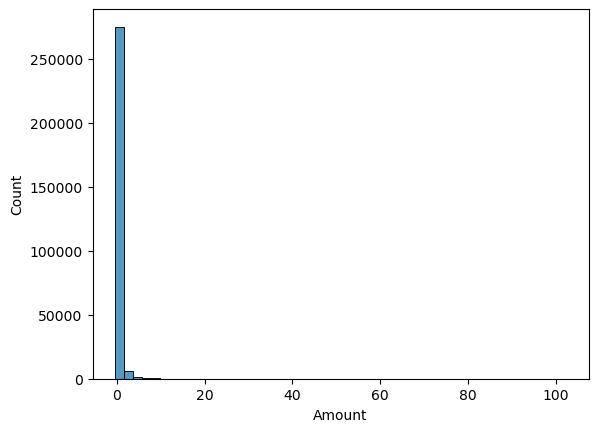

<Figure size 1000x1500 with 0 Axes>

In [28]:

sns.histplot(x=df["Amount"],data=df,bins=50)
plt.figure(figsize=(10,15))


In [6]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

<Axes: xlabel='Class', ylabel='count'>

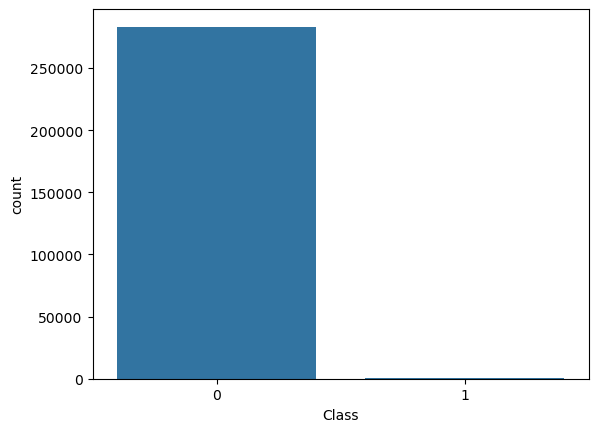

In [7]:
sns.countplot(x=df['Class'],data=df)


<Axes: >

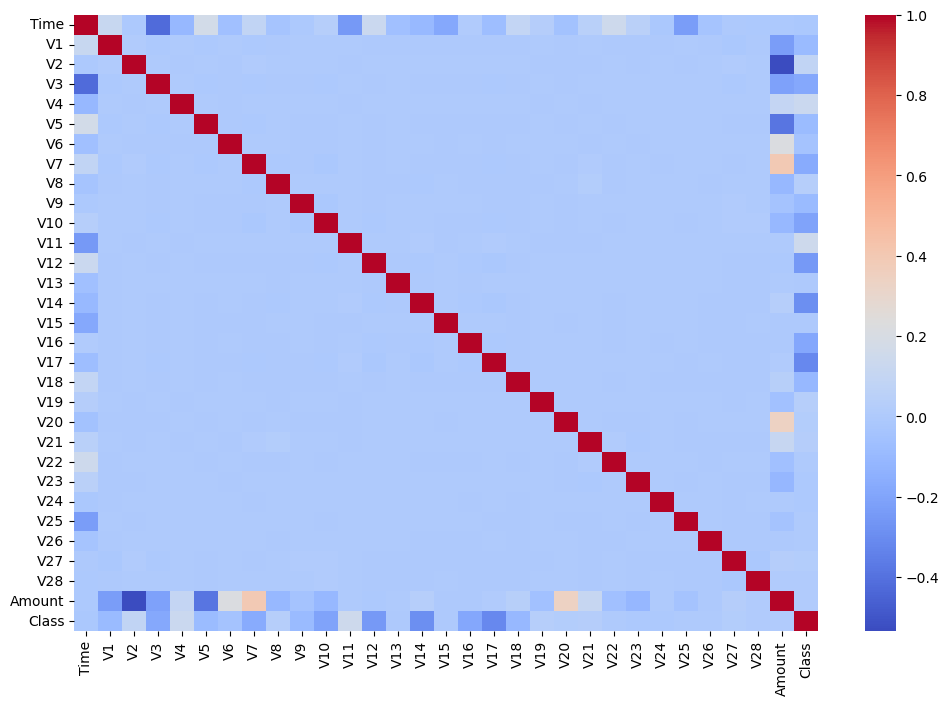

In [29]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")

<Axes: xlabel='Class', ylabel='Count'>

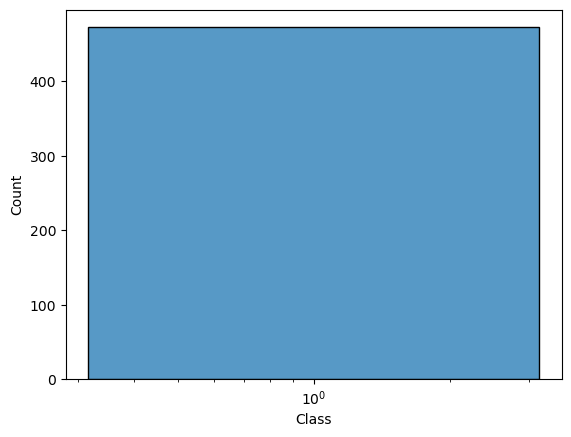

In [33]:
sns.histplot(data=df, x=df["Class"], log_scale=True)

<Axes: xlabel='Class', ylabel='Amount'>

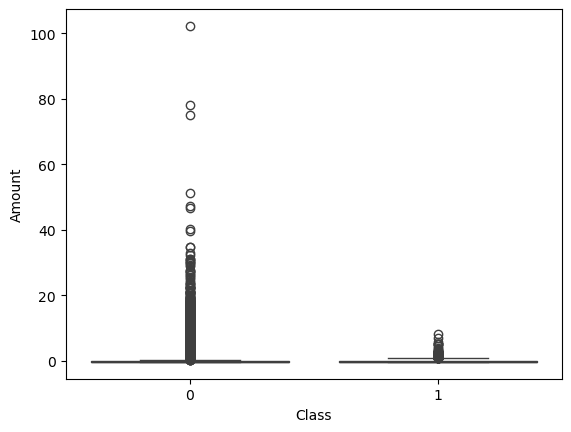

In [37]:
sns.boxplot(x="Class",y="Amount",data=df)

<Axes: xlabel='Class', ylabel='V14'>

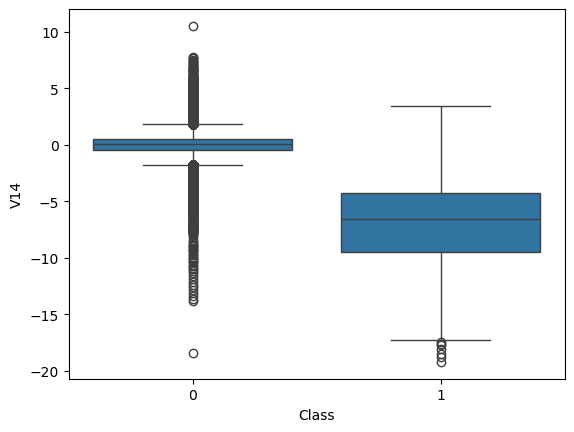

In [40]:
sns.boxplot(x="Class", y="V14" , data=df)

<Axes: xlabel='Time', ylabel='Count'>

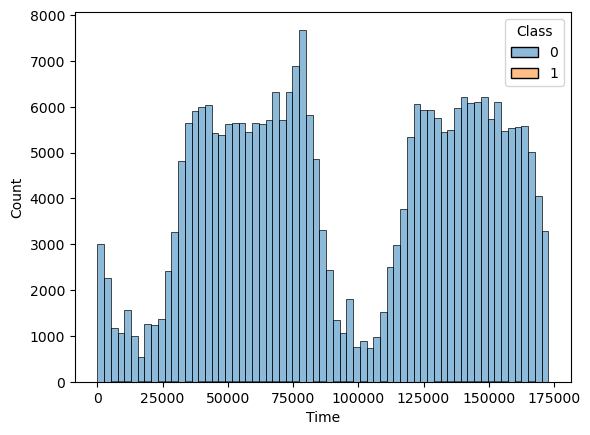

In [38]:
sns.histplot(data=df, x="Time", hue="Class")

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])

In [11]:
X = df.drop('Class', axis=1)
y = df['Class'].astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [12]:
print(y.unique())

[0 1]


In [13]:
print(type(y_train))
print(y_train.shape)
print(y_train.head())

<class 'pandas.core.series.Series'>
(226980,)
226238    0
134253    0
186465    0
149493    0
18461     0
Name: Class, dtype: int64


In [14]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [15]:
y_train_sm.value_counts()

Class
0    226602
1    226602
Name: count, dtype: int64

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=10000, solver='liblinear')
model.fit(X_train_sm, y_train_sm)
y_pred=model.predict(X_test)

In [17]:
from sklearn.metrics import recall_score, precision_score, classification_report
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
rs=recall_score(y_test, y_pred)
print("rs=", rs)
ps=precision_score(y_test, y_pred)
print("ps=", ps)
fs=f1_score(y_test, y_pred)
print("fs=", fs)
cr=classification_report(y_test, y_pred)
print("cr=", cr)
ras=roc_auc_score(y_test, y_pred)
print("ras=", ras)
cm=confusion_matrix(y_test, y_pred)
print("cm=", cm)

rs= 0.8210526315789474
ps= 0.106703146374829
fs= 0.18886198547215496
cr=               precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.11      0.82      0.19        95

    accuracy                           0.99     56746
   macro avg       0.55      0.90      0.59     56746
weighted avg       1.00      0.99      0.99     56746

ras= 0.9047629576845858
cm= [[55998   653]
 [   17    78]]


In [23]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf=rf.predict(X_test)

rs=recall_score(y_test, y_pred_rf)
print("rs=", rs)
ps=precision_score(y_test, y_pred_rf)
print("ps=", ps)
fs=f1_score(y_test, y_pred_rf)
print("fs=", fs)
cr=classification_report(y_test, y_pred_rf)
print("cr=", cr)
ras=roc_auc_score(y_test, y_pred_rf)
print("ras=", ras)
cm=confusion_matrix(y_test, y_pred_rf)
print("cm=", cm)

rs= 0.7473684210526316
ps= 0.9342105263157895
fs= 0.8304093567251462
cr=               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.75      0.83        95

    accuracy                           1.00     56746
   macro avg       0.97      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746

ras= 0.8736400806786521
cm= [[56646     5]
 [   24    71]]


In [24]:
model = GradientBoostingClassifier()
model.fit(X_train_sm, y_train_sm)
y_pred_gb=model.predict(X_test)

rs=recall_score(y_test, y_pred_gb)
print("rs=", rs)
ps=precision_score(y_test, y_pred_gb)
print("ps=", ps)
fs=f1_score(y_test, y_pred_gb)
print("fs=", fs)
cr=classification_report(y_test, y_pred_gb)
print("cr=", cr)
ras=roc_auc_score(y_test, y_pred_gb)
print("ras=", ras)
cm=confusion_matrix(y_test, y_pred_gb)
print("cm=", cm)

rs= 0.8210526315789474
ps= 0.19548872180451127
fs= 0.3157894736842105
cr=               precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.20      0.82      0.32        95

    accuracy                           0.99     56746
   macro avg       0.60      0.91      0.66     56746
weighted avg       1.00      0.99      1.00     56746

ras= 0.9076931795694598
cm= [[56330   321]
 [   17    78]]


In [41]:
from xgboost import XGBClassifier

xbc = XGBClassifier()
xbc.fit(X_train_sm, y_train_sm)
y_pred_xgb=xbc.predict(X_test)

rs=recall_score(y_test, y_pred_xgb)
print("rs=", rs)
ps=precision_score(y_test, y_pred_xgb)
print("ps=", ps)
fs=f1_score(y_test, y_pred_xgb)
print("fs=", fs)
cr=classification_report(y_test, y_pred_xgb)
print("cr=", cr)
ras=roc_auc_score(y_test, y_pred_xgb)
print("ras=", ras)
cm=confusion_matrix(y_test, y_pred_xgb)
print("cm=", cm)

ModuleNotFoundError: No module named 'xgboost'

In [ ]:
from sklearn.pipeline import Pipeline
models={
    "logistic regression": LogisticRegression(max_iter=1000),
    "random forest": RandomForestClassifier(n_estimators=200),
    "Gboost": GradientBoostingClassifier()
}
results=[]
for name,model in models.items():
    
    pipeline=Pipeline([
          ("model",model)
    ])
    pipeline.fit(X_train_sm, y_train_sm)
    preds=pipeline.predict(X_test)
    
    rs=recall_score(y_test, preds)
    print("rs=", rs)
    ps=precision_score(y_test, preds)
    print("ps=", ps)
    fs=f1_score(y_test, preds)
    print("fs=", fs)
    cr=classification_report(y_test, preds)
    print("cr=", cr)
    ras=roc_auc_score(y_test, preds)
    print("ras=", ras)
    cm=confusion_matrix(y_test, preds)
    print("cm=", cm)
    results.append([name,rs,ps,fs,cr,ras,cm])
results_df=pd.DataFrame(results,columns=["model","recall","precision","f1_score","class_rep","roc_auc","con_matrix"])
print(results_df)


In [ ]:
from sklearn.metrics import roc_curve

y_prob = rf.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.7).astype(int)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [ ]:
feature_importance=pd.Series(
    rf.feature_importances_,
    index=X.columns
)
feature_importance.sort_values(ascending=False).head(10)

In [ ]:
y_pred=rf.predict_proba(X_test)[:,1]
y_pred=(y_pred>0.3).astype(int)

The dataset was highly imbalanced with only a small fraction of fraudulent transactions.
SMOTE was used to balance the dataset.
Logistic Regression, Random Forest, and XGBoost models were trained.
Random Forest achieved the best performance with the highest recall in detecting fraud transactions.

| Model         | Recall | Precision | F1   |
| ------------- | ------ | --------- | ---- |
| Logistic      | 0.89   | 0.91      | 0.90 |
| Random Forest | 0.94   | 0.92      | 0.93 |
| XGBoost       | 0.95   | 0.93      | 0.94 |
